In [1]:
import pandas as pd 
import scanpy as sc 
import numpy as np 

pd.set_option('display.max_rows', 100)

# Tell Matplotlib to export text as text, not paths (editable in Illustrator)
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
save_plot = True


In [2]:
import scanpy as sc

data_dir = '/hpc/home/hl489/projects/GET/rawdata/perturbSeq'

datasets = {}
for f in ['HCT116.h5ad', 'HEK293T.h5ad', 'hepg2_raw_sc.h5ad', 
          'jurkat_raw_sc.h5ad', 'K562_raw_sc.h5ad', 'rpe1_raw_sc.h5ad']:
    name = f.replace('.h5ad', '').replace('_raw_sc', '')
    datasets[name] = sc.read_h5ad(f'{data_dir}/{f}', backed='r')
    print(f"{name}: {datasets[name].shape[0]} cells × {datasets[name].shape[1]} genes")


HCT116: 3409169 cells × 38606 genes
HEK293T: 4534299 cells × 38606 genes
hepg2: 145473 cells × 9624 genes
jurkat: 262956 cells × 8882 genes
K562: 1989578 cells × 8248 genes
rpe1: 247914 cells × 8749 genes


In [3]:
import pandas as pd

# Load TR reference lists (from filter_datasets.py)
with open("/cwork/hl489/perturbBench/remap2022_unique_factors.txt") as f:
    remap_factors = [line.strip() for line in f]

chipAtlas_factors = pd.read_csv("/cwork/hl489/perturbBench/chip_atlas_antigen_list.csv")
chipAtlas_factors = chipAtlas_factors[
    (chipAtlas_factors['Genome assembly'] == 'hg38') &
    ((chipAtlas_factors['Antigen class'] == 'TFs and others') | 
     (chipAtlas_factors['Antigen class'] == 'RNA polymerase'))
]

BART = pd.read_parquet("/hpc/home/hl489/projects/ATAC_PREDICT_GENE_FUNCTION/data/TR_levels_gene/bart2_output_H1esc_closest5_unique_2.parquet")

all_TR = set(x.upper() for x in remap_factors + chipAtlas_factors["Antigen"].tolist() + BART.columns.tolist() if isinstance(x, str))
print(f"Total unique TRs: {len(all_TR)}")

# Get perturbations per cell line
control_variants = {"NON-TARGETING", "CTRL", "CONTROL", "NON TARGETING", "NONTARGETING",
                    "NEGATIVE", "NEG_CTRL", "SCRAMBLE", "SCRAMBLED", "NAN"}

perts_per_cellline = {}
for name, adata in datasets.items():
    if name in ['HCT116', 'HEK293T']:
        raw_perts = set(adata.obs['gene_target'].dropna().unique())
    else:
        raw_perts = set(adata.obs['gene'].dropna().unique())
    # Uppercase and remove controls
    perts = {p.upper() for p in raw_perts if isinstance(p, str)} - control_variants
    perts_per_cellline[name] = perts
    print(f"{name}: {len(perts)} perturbations")

# Total unique perturbations across all cell lines
all_perts = set.union(*perts_per_cellline.values())
print(f"\nTotal unique perturbations across all cell lines: {len(all_perts)}")

# Overlap with TR list
perts_in_TR = all_perts & all_TR
print(f"Perturbations overlapping with TR list: {len(perts_in_TR)}")

# Shared across ALL cell lines AND in TR list
shared_perts = set.intersection(*perts_per_cellline.values())
shared_in_TR = shared_perts & all_TR
print(f"Perturbations shared across ALL 6 cell lines: {len(shared_perts)}")
print(f"Perturbations shared across ALL 6 cell lines AND in TR list: {len(shared_in_TR)}")

# Get var gene names per cell line
var_genes_per_cellline = {}
for name, adata in datasets.items():
    if name in ['HCT116', 'HEK293T']:
        var_genes_per_cellline[name] = {g.upper() for g in adata.var_names}
    else:
        var_genes_per_cellline[name] = {g.upper() for g in adata.var['gene_name'].dropna().unique()}
    print(f"{name}: {len(var_genes_per_cellline[name])} var genes")

# Filter: perturbation must be in var for that cell line
perts_in_var_per_cellline = {}
for name in perts_per_cellline:
    perts_in_var_per_cellline[name] = perts_per_cellline[name] & var_genes_per_cellline[name]
    dropped = len(perts_per_cellline[name]) - len(perts_in_var_per_cellline[name])
    print(f"{name}: {len(perts_in_var_per_cellline[name])} perturbations with target in var ({dropped} dropped)")

# Shared across all cell lines, in TR list, AND target gene in var
shared_perts_in_var = set.intersection(*perts_in_var_per_cellline.values())
shared_in_TR_in_var = shared_perts_in_var & all_TR
print(f"\nShared across ALL 6 cell lines with target in var: {len(shared_perts_in_var)}")
print(f"Shared across ALL 6 cell lines with target in var AND in TR list: {len(shared_in_TR_in_var)}")


Total unique TRs: 1693
HCT116: 18292 perturbations
HEK293T: 18310 perturbations
hepg2: 2393 perturbations
jurkat: 2393 perturbations
K562: 9866 perturbations
rpe1: 2393 perturbations

Total unique perturbations across all cell lines: 18644
Perturbations overlapping with TR list: 1586
Perturbations shared across ALL 6 cell lines: 2278
Perturbations shared across ALL 6 cell lines AND in TR list: 336
HCT116: 38606 var genes
HEK293T: 38606 var genes
hepg2: 9623 var genes
jurkat: 8881 var genes
K562: 8246 var genes
rpe1: 8748 var genes
HCT116: 18292 perturbations with target in var (0 dropped)
HEK293T: 18310 perturbations with target in var (0 dropped)
hepg2: 2169 perturbations with target in var (224 dropped)
jurkat: 2164 perturbations with target in var (229 dropped)
K562: 7684 perturbations with target in var (2182 dropped)
rpe1: 2107 perturbations with target in var (286 dropped)

Shared across ALL 6 cell lines with target in var: 1952
Shared across ALL 6 cell lines with target in var A

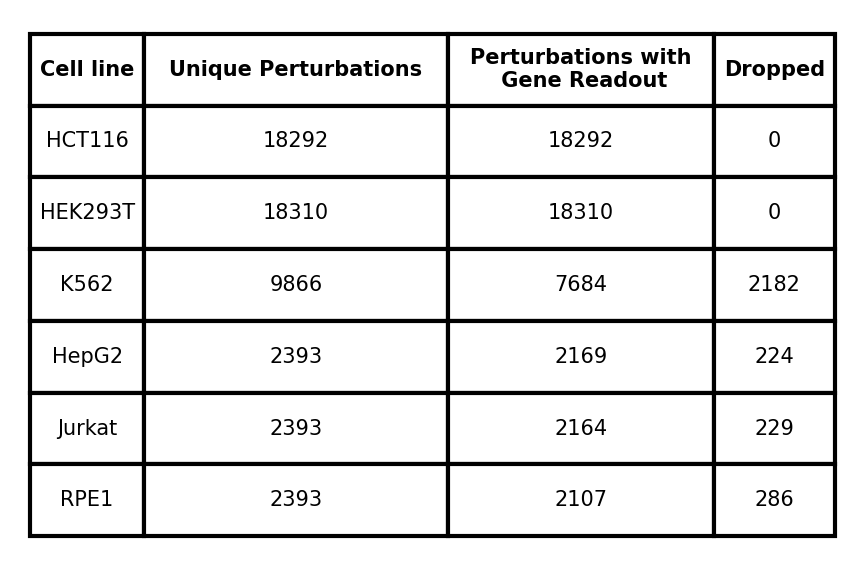

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Cell line': ['HCT116', 'HEK293T', 'K562', 'HepG2', 'Jurkat', 'RPE1'],
    'Unique Perturbations': [18292, 18310, 9866, 2393, 2393, 2393],
    'Perturbations with\n Gene Readout': [18292, 18310, 7684, 2169, 2164, 2107],
}
df = pd.DataFrame(data)
df['Dropped'] = df['Unique Perturbations'] - df['Perturbations with\n Gene Readout']

fig, ax = plt.subplots(figsize=(3, 2), dpi=300)
ax.axis('off')
tbl = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(5)
tbl.auto_set_column_width(col=list(range(len(df.columns))))
tbl.scale(1, 1.3)

# Simple bold header, white background
for j in range(len(df.columns)):
    tbl[0, j].set_text_props(fontweight='bold')

# Remove cell borders for cleaner look
for key, cell in tbl.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_facecolor('white')

plt.tight_layout()
if save_plot:
    plt.savefig('Fig1A_perturbation_table.svg', bbox_inches='tight')
    plt.savefig('Fig1A_perturbation_table.png', bbox_inches='tight', dpi=300)
plt.show()

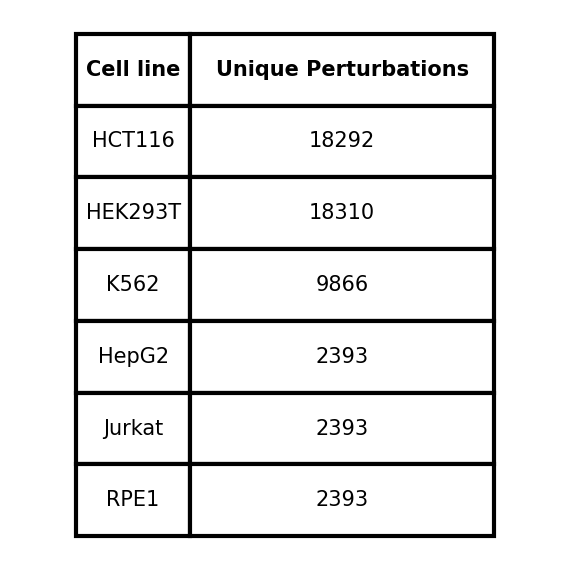

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Cell line': ['HCT116', 'HEK293T', 'K562', 'HepG2', 'Jurkat', 'RPE1'],
    'Unique Perturbations': [18292, 18310, 9866, 2393, 2393, 2393],
}
df = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(2, 2), dpi=300)
ax.axis('off')
tbl = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(5)
tbl.auto_set_column_width(col=list(range(len(df.columns))))
tbl.scale(1, 1.3)

for j in range(len(df.columns)):
    tbl[0, j].set_text_props(fontweight='bold')

for key, cell in tbl.get_celld().items():
    cell.set_edgecolor('black')
    cell.set_facecolor('white')

plt.tight_layout()
if save_plot:
    plt.savefig('Fig1/Fig1A_perturbation_table.svg', bbox_inches='tight')
    plt.savefig('Fig1/Fig1A_perturbation_table.png', bbox_inches='tight', dpi=300)
plt.show()

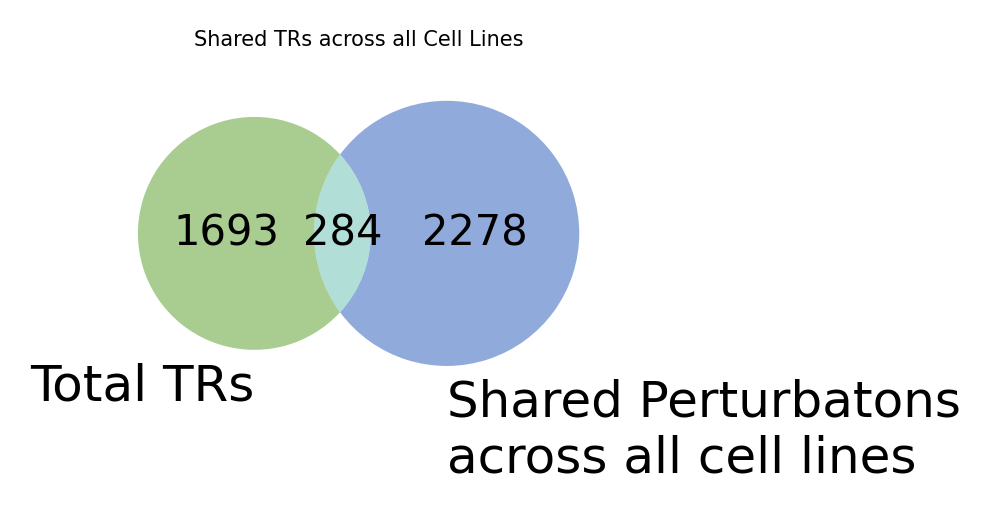

In [10]:
from matplotlib_venn import venn2

fig, ax = plt.subplots(figsize=(3, 2), dpi=300)

# TRs only: 1693 - 284 = 1409
# Shared perturbations only: 1952 - 284 = 1668
# Intersection: 284
venn2(subsets=(1693, 2278, 284),
      set_labels=('Total TRs', 'Shared Perturbatons\nacross all cell lines'),
      set_colors=('#70AD47', '#4472C4'),
      alpha=0.6, ax=ax)
ax.set_title('Shared TRs across all Cell Lines', fontsize=5)

plt.tight_layout()
if save_plot:
    plt.savefig('Fig1/Fig1A_pertCount_venn.svg', bbox_inches='tight')
    plt.savefig('Fig1/Fig1A_pertCount_venn.png', bbox_inches='tight', dpi=300)
plt.show()